#Project Title: Laptop Price Prediction for SmartTech Co.

#Project Overview:
SmartTech Co. has partnered with our data science team to develop a robust machine learning model that predicts laptop prices accurately. As the market for laptops continues to expand with a myriad of brands and specifications, having a precise pricing model becomes crucial for both consumers and manufacturers.

##Client's Objectives:
**Accurate Pricing:** Develop a model that can accurately predict laptop prices based on various features, helping our clients stay competitive in the market.

**Market Positioning:** Understand how different features contribute to pricing, enabling SmartTech Co. to strategically position its laptops in the market.

**Brand Influence:** Assess the impact of brand reputation on pricing, providing insights into brand perception and market demand.

##Key Challenges:
**Diverse Specifications:** The dataset encompasses laptops with diverse specifications. Our challenge is to build a model that generalizes well across a wide range of features.

**Real-time Prediction:** The model should have the capability to predict prices for newly released laptops, reflecting the fast-paced nature of the tech industry.

**Interpretability:** It is crucial to make the model interpretable, allowing SmartTech Co. to understand the rationale behind pricing predictions.

In [ ]:
#Import Necessary Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Filter out future warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [ ]:
#To Read CSV file
lap_data = pd.read_csv("https://s3.amazonaws.com/grey_campus/production/system/OdinSchool/2023/Edmingle/DataSet/laptop.zip")

##Data Understanding

In [ ]:
#Read Data Frame - First five rows
lap_data.head()

,Unnamed: 0.1,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [ ]:
# Shape of Data Frame
lap_data.shape

(1303, 13)

1. Columns - 13
2. Rows - 1303

In [ ]:
#Check duplicated rows
lap_data.duplicated().sum()

0

Hence, There are no duplicate rows

In [ ]:
#Structure of Data Frame
lap_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0.1      1303 non-null   int64  
 1   Unnamed: 0        1273 non-null   float64
 2   Company           1273 non-null   object 
 3   TypeName          1273 non-null   object 
 4   Inches            1273 non-null   object 
 5   ScreenResolution  1273 non-null   object 
 6   Cpu               1273 non-null   object 
 7   Ram               1273 non-null   object 
 8   Memory            1273 non-null   object 
 9   Gpu               1273 non-null   object 
 10  OpSys             1273 non-null   object 
 11  Weight            1273 non-null   object 
 12  Price             1273 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


Object Dtype - Text or mixed numeric and non-numeric values

In [ ]:
#Find Null values in the columns
lap_data.isnull().sum()

Unnamed: 0.1         0
Unnamed: 0          30
Company             30
TypeName            30
Inches              30
ScreenResolution    30
Cpu                 30
Ram                 30
Memory              30
Gpu                 30
OpSys               30
Weight              30
Price               30
dtype: int64

There are 30 missing values rows in the data frame.

In [ ]:
#Find which rows are the Null
data = lap_data[lap_data.isna().any(axis=1)]

In [ ]:
data
# Null Rows with specified numbers

,Unnamed: 0.1,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
20,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
115,115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125,125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
148,148,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
190,190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
209,209,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
267,267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
336,336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Counting Number of NaN(Not a Number) rows
data.count()

Unnamed: 0.1        30
Unnamed: 0           0
Company              0
TypeName             0
Inches               0
ScreenResolution     0
Cpu                  0
Ram                  0
Memory               0
Gpu                  0
OpSys                0
Weight               0
Price                0
dtype: int64

There are 30 rows.

In [ ]:
#Remove rows from the  data frame
lap_data.dropna(inplace=True)

Removing Rows instead of filling for better performance in the model

In [ ]:
#Checking Null Values
lap_data.isnull().sum()

Unnamed: 0.1        0
Unnamed: 0          0
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

No more Null Rows exist in the data frame

In [ ]:
#Dropping unrequired columns
lap_data.drop(columns=["Unnamed: 0.1","Unnamed: 0"], inplace=True)

In [ ]:
lap_data.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


Finding unique values in the columns

In [ ]:
#Inches Column
lap_data.Inches.unique()

array(['13.3', '15.6', '15.4', '14', '12', '17.3', '13.5', '12.5', '13',
       '18.4', '13.9', '11.6', '25.6', '35.6', '12.3', '27.3', '24',
       '33.5', '?', '31.6', '17', '15', '14.1', '11.3', '10.1'],
      dtype=object)

In [ ]:
#Weight Column
lap_data.Weight.unique()

array(['1.37kg', '1.34kg', '1.86kg', '1.83kg', '2.1kg', '2.04kg', '1.3kg',
       '1.6kg', '2.2kg', '0.92kg', '1.22kg', '2.5kg', '1.62kg', '1.91kg',
       '2.3kg', '1.35kg', '1.88kg', '1.89kg', '1.65kg', '2.71kg', '1.2kg',
       '1.44kg', '2.8kg', '2kg', '2.65kg', '2.77kg', '3.2kg', '1.49kg',
       '2.4kg', '2.13kg', '2.43kg', '1.7kg', '1.4kg', '1.8kg', '1.9kg',
       '3kg', '1.252kg', '2.7kg', '2.02kg', '1.63kg', '1.96kg', '1.21kg',
       '2.45kg', '1.25kg', '1.5kg', '2.62kg', '1.38kg', '1.58kg',
       '1.85kg', '1.23kg', '2.16kg', '2.36kg', '7.2kg', '2.05kg',
       '1.32kg', '1.75kg', '0.97kg', '2.56kg', '1.48kg', '1.74kg',
       '1.1kg', '1.56kg', '2.03kg', '1.05kg', '5.4kg', '4.4kg', '1.90kg',
       '1.29kg', '2.0kg', '1.95kg', '2.06kg', '1.12kg', '3.49kg',
       '3.35kg', '2.23kg', '?', '2.9kg', '4.42kg', '2.69kg', '2.37kg',
       '4.7kg', '3.6kg', '2.08kg', '4.3kg', '1.68kg', '1.41kg', '4.14kg',
       '2.18kg', '2.24kg', '2.67kg', '4.1kg', '2.14kg', '1.36kg',
       '

In [ ]:
#Ram Column
lap_data.Ram.unique()

array(['8GB', '16GB', '4GB', '2GB', '12GB', '64GB', '6GB', '32GB', '24GB',
       '1GB'], dtype=object)

In both Weight and Inches columns '?' is present. which leads to error

**Handling '?' using Imputation methods**

In [ ]:
# Convert 'Weight & Inches' column to string data type
lap_data['Weight'] = lap_data['Weight'].astype(str)
lap_data['Inches'] = lap_data['Inches'].astype(str)

In [ ]:
# Replace '?' with NaN in both the columns
# Replace '?' with NaN in both the columns
lap_data['Weight'] = lap_data['Weight'].str.replace("?", "NaN", regex=False)
lap_data['Inches'] = lap_data['Inches'].str.replace("?", "NaN", regex=False)

In [ ]:
#Fill missing values using Mode
lap_data['Weight'].fillna(lap_data['Weight'].mode().iloc[0], inplace=True)
lap_data['Inches'].fillna(lap_data['Inches'].mode().iloc[0], inplace=True)

In [ ]:
#Convert Str to Int type
lap_data['Inches'] = lap_data['Inches'].astype(float)

**Remove GB and Kg from 'Ram' and 'Weight' and convert the cols to numeric**

In [ ]:
## RAM

# Convert 'Ram' column to string data type
lap_data['Ram'] = lap_data['Ram'].astype(str)

#Replace 'GB' with empty string in 'Ram' Column
lap_data['Ram'] = lap_data['Ram'].str.replace("GB", "")


# Convert 'Ram' column from string to integer data type
lap_data['Ram'] = lap_data['Ram'].astype(int)

In [ ]:
## Laptop Weight

#Replace 'kg' with empty string in 'Weight' Column
lap_data['Weight'] = lap_data['Weight'].str.replace("kg", '')

# Convert 'Weight' column from string to float data type
lap_data['Weight'] = lap_data['Weight'].astype(float)

In [ ]:
lap_data.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080


In [ ]:
lap_data.isnull().sum()

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

##Exploratory Data Analysis

Price Distribution

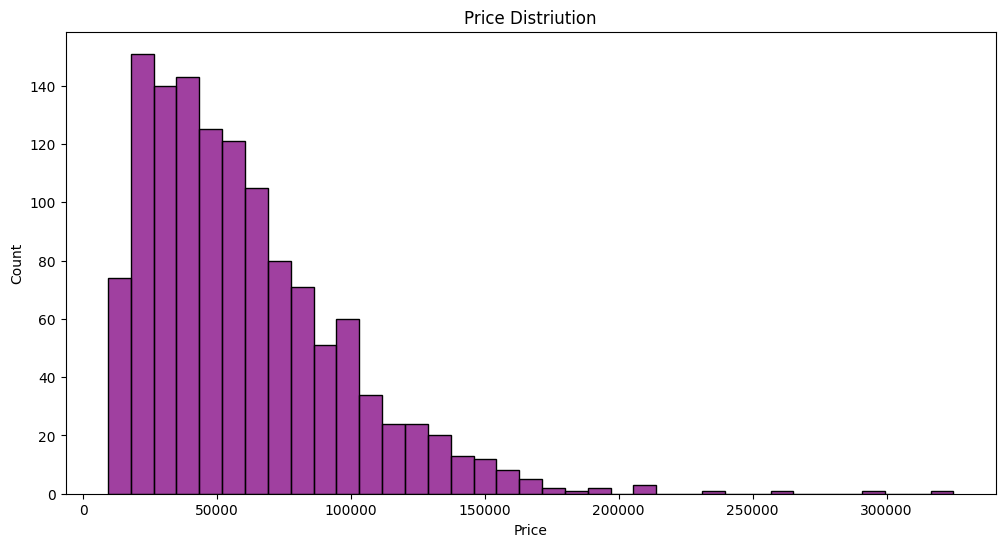

In [ ]:
# setting the dimensions of the plot
fig = plt.subplots(figsize=(12, 6))

#Plot configuration
sns.histplot(lap_data['Price'], color = 'purple', edgecolor = 'black')

#Plot Ttile
plt.title("Price Distriution")
plt.show()

Company

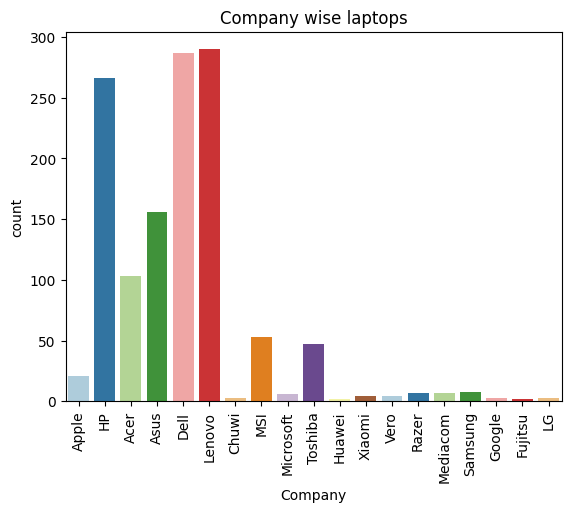

In [ ]:
#Company wise laptops -------------
sns.countplot(x='Company', hue='Company', data=lap_data, palette='Paired', legend=False)
plt.xticks(rotation='vertical')
plt.title("Company wise laptops")
plt.show()

**Insights** :
1. Lenovo, Dell and HP are most purchased product by customers.
2. Acer, Asus, MSI and Tobshiba companies have decent market.
3. Apple is costly and less sales compared to other brands.
4. Remaining brands are not performing well.

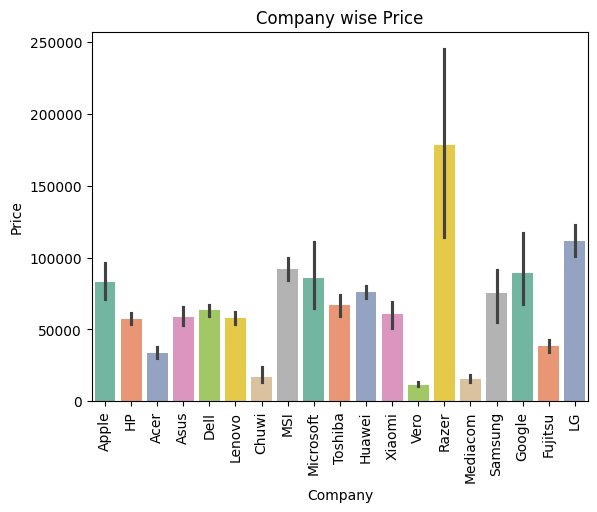

In [ ]:
#Company with Price ---------------
sns.barplot(x="Company", y="Price", data=lap_data,hue="Company", palette="Set2")
plt.xticks(rotation='vertical')
plt.title("Company wise Price")
plt.show()

In [ ]:
lap_data.Company.unique()

array(['Apple', 'HP', 'Acer', 'Asus', 'Dell', 'Lenovo', 'Chuwi', 'MSI',
       'Microsoft', 'Toshiba', 'Huawei', 'Xiaomi', 'Vero', 'Razer',
       'Mediacom', 'Samsung', 'Google', 'Fujitsu', 'LG'], dtype=object)

**Insights :**
1. Razer brand laptops are the costliest among other brands.
2. After Razer brand price followed by LG, Google, Microsoft, MSI, Apple.
3. But Market captured by HP,Dell, Lenovo, Asus, Acer etc.. and the price range between 20k to 60k.

Type of Laptop 💻

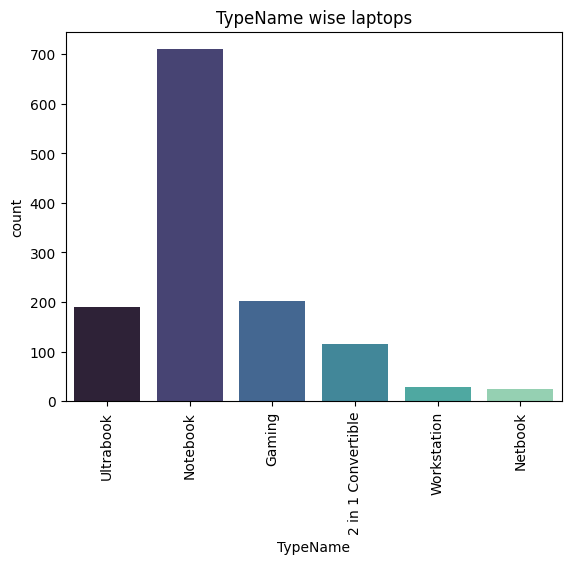

In [ ]:
#TypeName wise laptops-------------
sns.countplot(x ='TypeName', data = lap_data,hue="TypeName", palette ='mako')
plt.xticks(rotation='vertical')
plt.title("TypeName wise laptops")
plt.show()

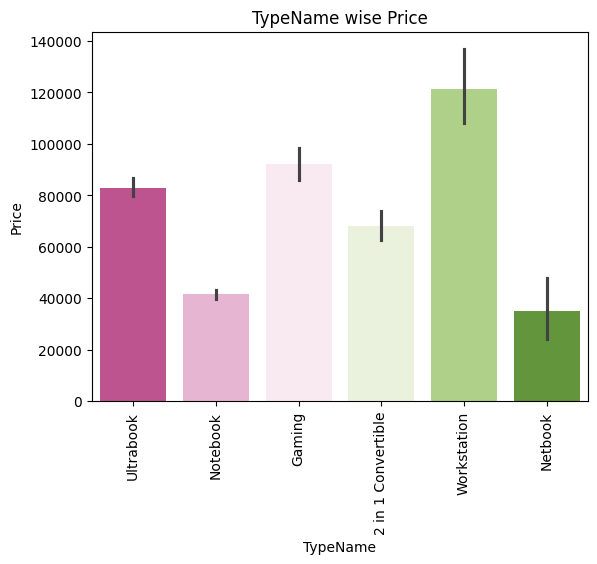

In [ ]:
#TypeName with Price---------------
sns.barplot(x="TypeName", y="Price", data=lap_data,hue="TypeName", palette="PiYG")
plt.xticks(rotation='vertical')
plt.title("TypeName wise Price")
plt.show()

Inches

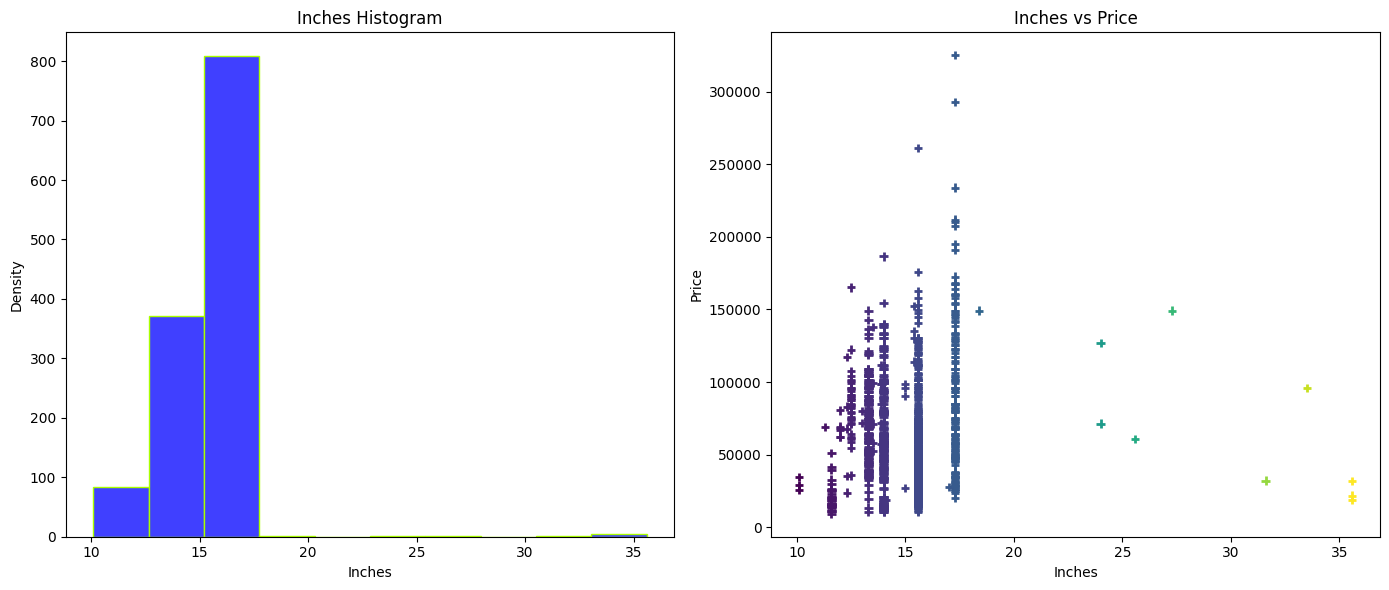

In [ ]:
# Create subplots with 1 row and 2 columns
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Plot histogram
sns.histplot(lap_data['Inches'], ax=axs[0], color='blue', edgecolor='#aaff00',bins=10)
axs[0].set_title("Inches Histogram")
axs[0].set_xlabel("Inches")
axs[0].set_ylabel("Density")

# Plot scatterplot -- Price Vs Inches
sns.scatterplot(x="Inches", y="Price", hue="Inches", marker='+', data=lap_data, ax=axs[1],palette='viridis', linewidths=2,legend=False)
axs[1].set_title("Inches vs Price")
axs[1].set_xlabel("Inches")
axs[1].set_ylabel("Price")

# Adjust layout to prevent overlap
plt.tight_layout()

# Show plots
plt.show()

**Feature engineering** is the process of transforming raw data into features that better represent the underlying problem to the predictive models, resulting in improved model performance.


Exploring & Feature Engineering(FE) - **Screen Resolution**

In [ ]:
lap_data['ScreenResolution'].value_counts()

Full HD 1920x1080                                495
1366x768                                         274
IPS Panel Full HD 1920x1080                      226
IPS Panel Full HD / Touchscreen 1920x1080         52
Full HD / Touchscreen 1920x1080                   45
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  14
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160                9
4K Ultra HD 3840x2160                              7
IPS Panel 1366x768                                 7
IPS Panel Retina Display 2560x1600                 6
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
Touchscreen 2560x1440                              6
IPS Panel Retina Display 2304x1440                 6
Touchscreen 2256x1504                              6
IPS Panel Touchscreen 2560x1440               

There are different types of screens/displays are available. It is required to classify/categorize laptops based on screen type for better price predication

In [ ]:
#Split the column based on Touchscreen - True = 1 and False = 0
lap_data['Touchscreen'] = lap_data['ScreenResolution'].apply(lambda x: 1 if 'Touchscreen' in x else 0)
lap_data['IPS'] = lap_data['ScreenResolution'].apply(lambda x: 1 if 'IPS' in x else 0)

In [ ]:
# Random 10 rows from the data frame
lap_data.sample(10)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS
1110,HP,Notebook,13.3,Quad HD+ / Touchscreen 3200x1800,Intel Core M 6Y54 1.1GHz,8,256GB SSD,Intel HD Graphics 515,Windows 10,1.16,90522.72,1,0
17,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.9GHz,16,512GB SSD,AMD Radeon Pro 560,macOS,1.83,152274.24,0,1
883,Lenovo,Notebook,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 6500U 2.5GHz,8,1TB HDD,Nvidia GeForce 940MX,Windows 10,2.20,35644.32,0,1
285,Acer,Notebook,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 7500U 2.7GHz,12,1TB HDD,Intel HD Graphics 620,Windows 10,2.15,35111.52,1,1
526,Lenovo,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,4,1TB HDD,Nvidia GeForce 920MX,Windows 10,2.20,42570.72,0,0
217,HP,Notebook,14.0,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,8,256GB SSD,Nvidia GeForce 930MX,Windows 10,1.63,54931.68,0,0
232,Lenovo,Gaming,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows 10,3.20,79866.72,0,1
259,Lenovo,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 7700HQ 2.8GHz,8,512GB SSD,Nvidia GeForce GTX 1050M,Windows 10,2.00,90522.72,1,1
765,Acer,Notebook,13.3,1366x768,Intel Core i5 6200U 2.3GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.60,34898.40,0,0
1083,HP,Ultrabook,13.3,IPS Panel 4K Ultra HD 3840x2160,Intel Core i7 7500U 2.7GHz,16,512GB SSD,Intel HD Graphics 620,Windows 10,1.30,109170.72,0,1


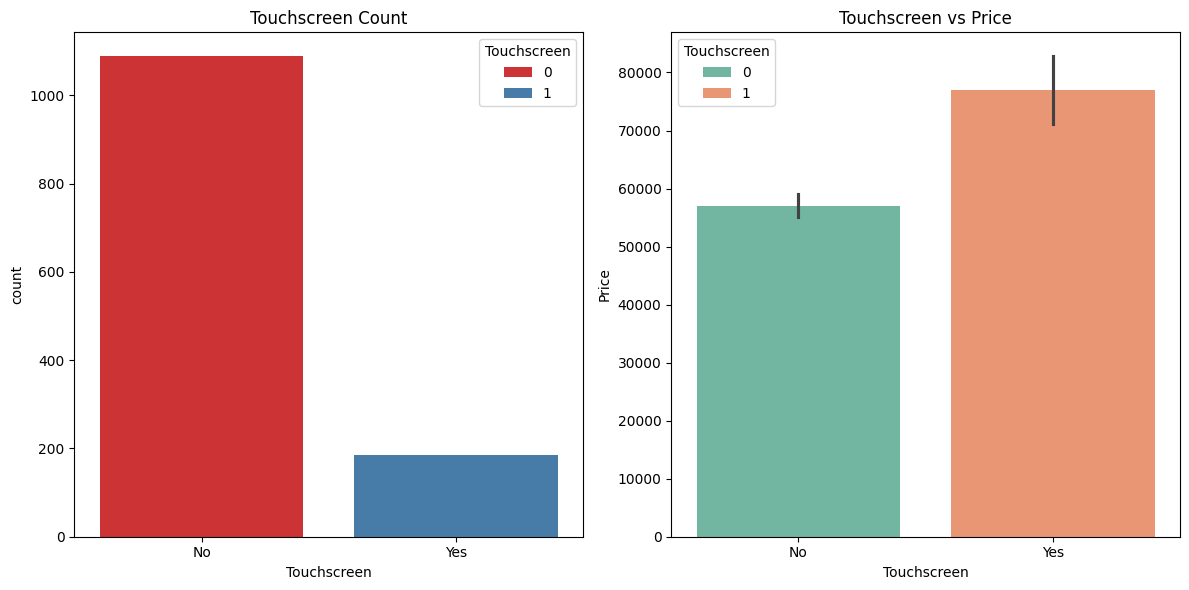

In [ ]:
# Define the mapping of labels
label_mapping = {0: 'No', 1: 'Yes'}

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Touchscreen Countplot
sns.countplot(x='Touchscreen', hue='Touchscreen', data=lap_data, palette='Set1', ax=axs[0])
axs[0].set_xticks([0, 1])
axs[0].set_xticklabels([label_mapping[0], label_mapping[1]])
axs[0].set_title("Touchscreen Count")

# Touchscreen Barplot
sns.barplot(x='Touchscreen', y='Price', hue='Touchscreen', data=lap_data, palette='Set2', ax=axs[1])
axs[1].set_xticks([0, 1])
axs[1].set_xticklabels([label_mapping[0], label_mapping[1]])
axs[1].set_title("Touchscreen vs Price")

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()

In [ ]:
# Available palette
print(plt.colormaps())

['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted_r', 'turbo_r', 'Blues_r', 'BrBG_r', 'BuGn_r', 'BuPu_r', 'CMRmap_r', 'GnBu_r', 'G

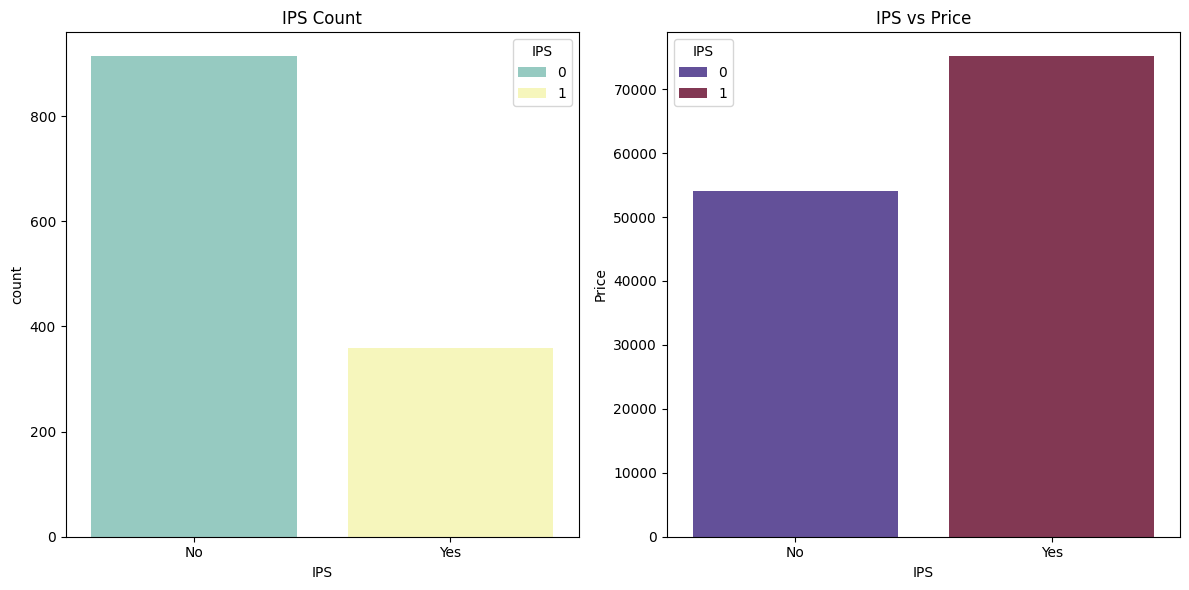

In [ ]:
# Define the mapping of labels
label_mapping = {0: 'No', 1: 'Yes'}

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# IPS Countplot
sns.countplot(x='IPS', hue='IPS', data=lap_data, palette='Set3', ax=axs[0])
axs[0].set_xticks([0, 1])
axs[0].set_xticklabels([label_mapping[0], label_mapping[1]])
axs[0].set_title("IPS Count")

# IPS Barplot
sns.barplot(x='IPS', y='Price', hue='IPS',errorbar=None, data=lap_data, palette='twilight', ax=axs[1])
axs[1].set_xticks([0, 1])
axs[1].set_xticklabels([label_mapping[0], label_mapping[1]])
axs[1].set_title("IPS vs Price")

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()


In [ ]:
# Dividing Screen Resolution and create a new data frame
new_df = lap_data['ScreenResolution'].str.split('x',n=1,expand=True)

#This splits each string in the 'ScreenResolution' column into substrings using the separator 'x'.
#The n parameter is set to 1, which means the splitting will only occur at the first occurrence of 'x'.
#The expand=True parameter tells Pandas to return a DataFrame with the split components in separate columns.

The number of pixels across the width and height of the image is called the resolution. An image with 640 pixels across the width and 480 pixels high has a resolution of 640x480. The more pixels in the image file, the higher the resolution.

In [ ]:
# Split 'ScreenResolution' into numeric components for width and height
new_df = lap_data['ScreenResolution'].str.extract(r'(\d+)x(\d+)')
new_df.columns = ['Width', 'Height']

print(new_df)

     Width Height
0     2560   1600
1     1440    900
2     1920   1080
3     2880   1800
4     2560   1600
...    ...    ...
1298  1920   1080
1299  3200   1800
1300  1366    768
1301  1366    768
1302  1366    768

[1273 rows x 2 columns]


In [ ]:
#Add new_df to lap_data
lap_data['X_res_width'] = new_df["Width"]
lap_data['Y_res_height'] = new_df["Height"]

In [ ]:
lap_data.sample(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,X_res_width,Y_res_height
288,Lenovo,Gaming,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1050 Ti,Windows 10,2.5,62817.12,0,1,1920,1080
704,Lenovo,Notebook,15.6,1366x768,Intel Core i3 6006U 2GHz,4,500GB HDD,Intel HD Graphics 520,No OS,1.9,23976.00,0,0,1366,768
152,Lenovo,Notebook,15.6,1366x768,Intel Core i5 7200U 2.5GHz,4,128GB SSD,Intel HD Graphics 620,Windows 10,1.9,26533.44,0,0,1366,768
643,Asus,Gaming,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8,1TB HDD,Nvidia GeForce GTX 1050 Ti,No OS,2.5,62284.32,0,1,1920,1080
676,Asus,Ultrabook,14.0,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,Windows 10,1.1,60472.80,0,0,1920,1080


In [ ]:
#Convert Str to Int data type
lap_data['X_res_width'] = lap_data['X_res_width'].astype('int')
lap_data['Y_res_height'] = lap_data['Y_res_height'].astype('int')

In [ ]:
lap_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1273 entries, 0 to 1302
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1273 non-null   object 
 1   TypeName          1273 non-null   object 
 2   Inches            1273 non-null   float64
 3   ScreenResolution  1273 non-null   object 
 4   Cpu               1273 non-null   object 
 5   Ram               1273 non-null   int64  
 6   Memory            1273 non-null   object 
 7   Gpu               1273 non-null   object 
 8   OpSys             1273 non-null   object 
 9   Weight            1273 non-null   float64
 10  Price             1273 non-null   float64
 11  Touchscreen       1273 non-null   int64  
 12  IPS               1273 non-null   int64  
 13  X_res_width       1273 non-null   int64  
 14  Y_res_height      1273 non-null   int64  
dtypes: float64(3), int64(5), object(7)
memory usage: 159.1+ KB


###Exploring & Feature Engineering(FE) - **Price**

In [ ]:
# Correlation
lap_data.corr()['Price']

Inches          0.044966
Ram             0.685648
Weight          0.175966
Price           1.000000
Touchscreen     0.188994
IPS             0.254851
X_res_width     0.557556
Y_res_height    0.554069
Name: Price, dtype: float64

In [ ]:
# Calculate pixel density (PPI) using the formula:
# PPI = square root of (square of X resolution + square of Y resolution) divided by screen size (in inches)
lap_data['PPI'] = (((lap_data['X_res_width'] ** 2) + (lap_data['Y_res_height'] ** 2)) ** 0.5 / lap_data['Inches']).astype('float')

In [ ]:
# Correlation
lap_data.corr()['Price']

Inches          0.044966
Ram             0.685648
Weight          0.175966
Price           1.000000
Touchscreen     0.188994
IPS             0.254851
X_res_width     0.557556
Y_res_height    0.554069
PPI             0.468636
Name: Price, dtype: float64

In [ ]:
lap_data.sample(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,X_res_width,Y_res_height,PPI
1118,Toshiba,Ultrabook,13.3,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,16,512GB SSD,Intel HD Graphics 620,Windows 10,1.05,118601.280,0,0,1920,1080,165.632118
340,Dell,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4,500GB HDD,Intel HD Graphics,Linux,2.20,14646.672,0,0,1366,768,100.454670
803,Dell,Notebook,15.6,4K Ultra HD / Touchscreen 3840x2160,Intel Core i5 7300HQ 2.5GHz,8,256GB SSD,Nvidia GeForce GTX 1050,Windows 10,2.06,93186.720,1,0,3840,2160,282.423996
299,Asus,Ultrabook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,16,512GB SSD,Nvidia GeForce 940MX,Windows 10,1.63,78215.040,0,0,1920,1080,141.211998
1029,HP,Notebook,17.3,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Nvidia GeForce 930MX,Windows 10,2.63,57542.400,0,0,1920,1080,127.335675


In [ ]:
#Drop Screenresolution, Inches, X_res_width and Y_res_height
lap_data.drop(columns=['ScreenResolution','Inches','X_res_width','Y_res_height'],inplace=True)

In [ ]:
lap_data.sample(2)

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,PPI
231,HP,Notebook,AMD E-Series 9000e 1.5GHz,4,500GB HDD,AMD Radeon R2,Windows 10,2.1,17582.40,0,0,100.454670
1215,Acer,Netbook,Intel Celeron Dual Core 3205U 1.5GHz,2,32GB SSD,Intel HD Graphics,Chrome OS,1.3,9270.72,0,0,135.094211


### Exploring & FE - **CPU**

In [ ]:
# Unique Values in the CPU column
lap_data.Cpu.unique()

array(['Intel Core i5 2.3GHz', 'Intel Core i5 1.8GHz',
       'Intel Core i5 7200U 2.5GHz', 'Intel Core i7 2.7GHz',
       'Intel Core i5 3.1GHz', 'AMD A9-Series 9420 3GHz',
       'Intel Core i7 2.2GHz', 'Intel Core i7 8550U 1.8GHz',
       'Intel Core i5 8250U 1.6GHz', 'Intel Core i3 6006U 2GHz',
       'Intel Core i7 2.8GHz', 'Intel Core M m3 1.2GHz',
       'Intel Core i7 7500U 2.7GHz', 'Intel Core i7 2.9GHz',
       'Intel Core i3 7100U 2.4GHz', 'Intel Core i5 7300HQ 2.5GHz',
       'AMD E-Series E2-9000e 1.5GHz', 'Intel Core i5 1.6GHz',
       'Intel Core i7 8650U 1.9GHz', 'Intel Atom x5-Z8300 1.44GHz',
       'AMD E-Series E2-6110 1.5GHz', 'AMD A6-Series 9220 2.5GHz',
       'Intel Celeron Dual Core N3350 1.1GHz',
       'Intel Core i3 7130U 2.7GHz', 'Intel Core i7 7700HQ 2.8GHz',
       'Intel Core i5 2.0GHz', 'AMD Ryzen 1700 3GHz',
       'Intel Pentium Quad Core N4200 1.1GHz',
       'Intel Celeron Dual Core N3060 1.6GHz', 'Intel Core i5 1.3GHz',
       'AMD FX 9830P 3GHz', '

In [ ]:
import re

# Define a regular expression pattern to match the CPU brand
pattern = r'^(.*?)\s(?:\w+-?\w+\s)?\d+(\.\d+)?GHz'

# Extract CPU brand
lap_data["CPU_Name"] = [re.match(pattern, cpu).group(1) for cpu in lap_data['Cpu']]

In [ ]:
lap_data.sample(5)

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,PPI,CPU_Name
1058,Dell,2 in 1 Convertible,Intel Core i7 7500U 2.7GHz,12,256GB SSD,Intel HD Graphics 620,Windows 10,1.60,69210.72,1,1,165.632118,Intel Core i7
359,Dell,Notebook,Intel Core i5 7300U 2.6GHz,8,256GB SSD,Intel HD Graphics 620,Windows 10,1.36,76030.56,0,0,157.350512,Intel Core i5
35,Lenovo,Notebook,Intel Celeron Dual Core N3350 1.1GHz,4,64GB Flash Storage,Intel HD Graphics 500,Windows 10,1.44,13266.72,0,0,111.935204,Intel Celeron Dual Core
116,HP,Notebook,Intel Core i7 8550U 1.8GHz,8,512GB SSD,Intel UHD Graphics 620,Windows 10,1.63,57755.52,0,0,157.350512,Intel Core i7
395,HP,Ultrabook,AMD A9-Series 9420 3GHz,4,256GB SSD,AMD Radeon 520,Windows 10,1.91,26586.72,0,0,141.211998,AMD A9-Series


In [ ]:
#CPU name extration function
def fetch_processor(text):
    if text == 'Intel Core i7' or text == 'Intel Core i5' or text == 'Intel Core i3':
        return text
    else:
        if text.split()[0] == 'Intel':
            return 'Other Intel Processor'
        else:
            return 'AMD Processor'

In [ ]:
lap_data['Cpu brand'] = lap_data["CPU_Name"].apply(fetch_processor)

In [ ]:
lap_data.sample(2)

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,PPI,CPU_Name,Cpu brand
1272,Lenovo,Notebook,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.50,12201.12,0,0,111.935204,Intel Celeron Dual Core,Other Intel Processor
1077,MSI,Gaming,Intel Core i7 7700HQ 2.8GHz,16,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,3.78,133146.72,0,0,127.335675,Intel Core i7,Intel Core i7


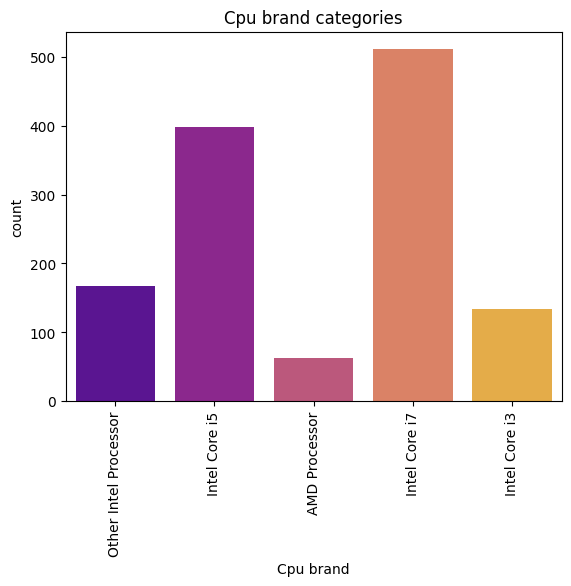

In [ ]:
# Plot count of CPU brand categories
sns.countplot(x='Cpu brand', data=lap_data, palette='plasma')
plt.xticks(rotation='vertical')
plt.title('Cpu brand categories')
plt.show()

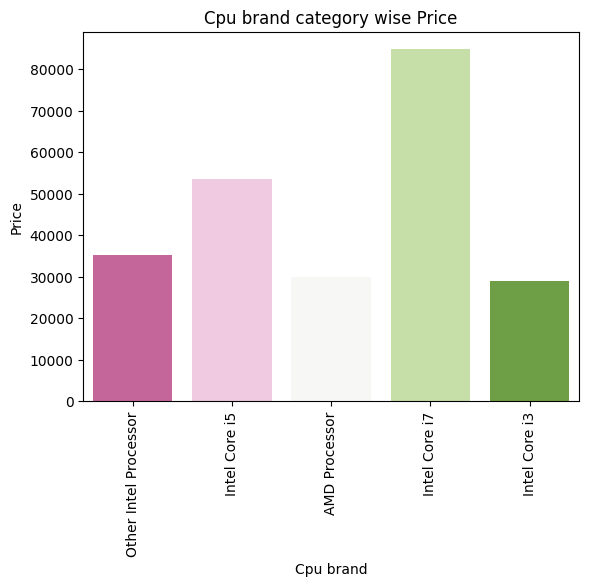

In [ ]:
# Plot Bar on  price by CPU brand category
sns.barplot(x='Cpu brand', y='Price', data=lap_data, palette='PiYG', errorbar=None)
plt.xticks(rotation='vertical')
plt.title('Cpu brand category wise Price')
plt.show()

In [ ]:
#drop cpu name
lap_data.drop(columns=['CPU_Name','Cpu'],inplace=True)

In [ ]:
lap_data.sample(2)

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,PPI,Cpu brand
1217,Lenovo,Notebook,8,1TB HDD,Intel HD Graphics 620,No OS,2.8,28717.92,0,0,106.113062,Intel Core i5
378,Asus,Notebook,4,32GB Flash Storage,Intel HD Graphics 500,Windows 10,1.5,15238.08,0,0,111.935204,Other Intel Processor


### EDA - RAM

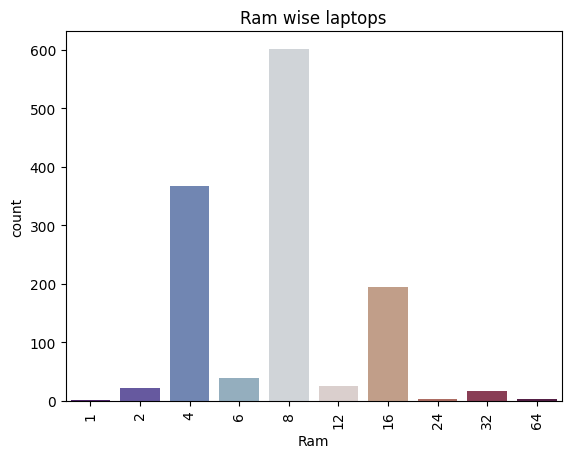

In [ ]:
# RAM Countplot
sns.countplot(x='Ram', data=lap_data, palette='twilight_shifted')
plt.xticks(rotation='vertical')
plt.title("Ram wise laptops")
plt.show()

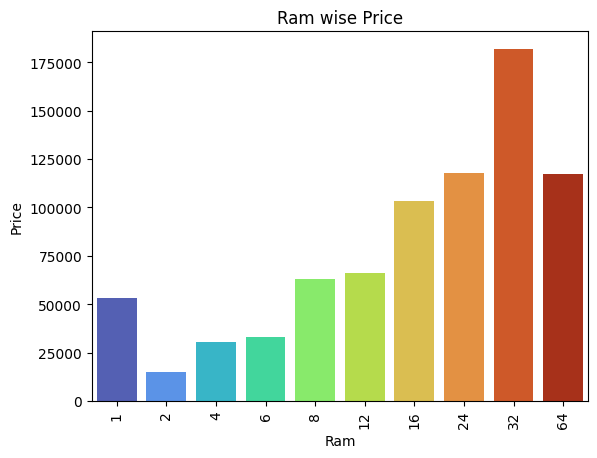

In [ ]:
# RAM Barplot
sns.barplot(x='Ram', y='Price', data=lap_data, palette='turbo',errorbar=None)
plt.xticks(rotation='vertical')
plt.title("Ram wise Price")
plt.show()

### Exploring & FE - **Memory**

In [ ]:
lap_data['Memory'].value_counts()

256GB SSD                        401
1TB HDD                          217
500GB HDD                        130
512GB SSD                        116
128GB SSD +  1TB HDD              92
128GB SSD                         74
256GB SSD +  1TB HDD              71
32GB Flash Storage                37
2TB HDD                           16
64GB Flash Storage                14
512GB SSD +  1TB HDD              14
1TB SSD                           13
256GB SSD +  2TB HDD              10
1.0TB Hybrid                       9
256GB Flash Storage                8
16GB Flash Storage                 7
32GB SSD                           6
180GB SSD                          4
128GB Flash Storage                4
512GB SSD +  2TB HDD               3
16GB SSD                           3
512GB Flash Storage                2
1TB SSD +  1TB HDD                 2
128GB SSD +  2TB HDD               2
256GB SSD +  500GB HDD             2
256GB SSD +  256GB SSD             2
512GB SSD +  256GB SSD             1
5

In [ ]:
import pandas as pd

# Replace ".0" with an empty string
lap_data['Memory'] = lap_data['Memory'].astype(str).replace('\.0', '', regex=True)

# Remove 'GB' and replace 'TB' with '000'
lap_data["Memory"] = lap_data["Memory"].str.replace('GB', '').str.replace('TB', '000')

# Split the memory column into two columns based on '+'
new = lap_data["Memory"].str.split("+", n=1, expand=True)

# Extract the first layer memory information
lap_data["Layer1"] = new[0].str.strip()
lap_data["Layer1HDD"] = lap_data["Layer1"].str.contains('HDD', case=False).astype(int)
lap_data["Layer1SSD"] = lap_data["Layer1"].str.contains('SSD', case=False).astype(int)
lap_data["Layer1Hybrid"] = lap_data["Layer1"].str.contains('Hybrid', case=False).astype(int)
lap_data["Layer1Flash_Storage"] = lap_data["Layer1"].str.contains('Flash Storage', case=False).astype(int)
lap_data['Layer1'] = lap_data['Layer1'].str.replace(r'\D', '').replace('', '0')
lap_data['Layer1'] = lap_data['Layer1'].astype(int)

# Extract the second layer memory information
lap_data["Layer2"] = new[1].fillna("0").str.strip()
lap_data["Layer2HDD"] = lap_data["Layer2"].str.contains('HDD', case=False).astype(int)
lap_data["Layer2SSD"] = lap_data["Layer2"].str.contains('SSD', case=False).astype(int)
lap_data["Layer2Hybrid"] = lap_data["Layer2"].str.contains('Hybrid', case=False).astype(int)
lap_data["Layer2Flash_Storage"] = lap_data["Layer2"].str.contains('Flash Storage', case=False).astype(int)
lap_data['Layer2'] = lap_data['Layer2'].str.replace(r'\D', '').replace('', '0')
lap_data['Layer2'] = lap_data['Layer2'].astype(int)

# Calculate HDD, SSD, Hybrid, and Flash_Storage
lap_data["HDD"] = (lap_data["Layer1"] * lap_data["Layer1HDD"] + lap_data["Layer2"] * lap_data["Layer2HDD"])
lap_data["SSD"] = (lap_data["Layer1"] * lap_data["Layer1SSD"] + lap_data["Layer2"] * lap_data["Layer2SSD"])
lap_data["Hybrid"] = (lap_data["Layer1"] * lap_data["Layer1Hybrid"] + lap_data["Layer2"] * lap_data["Layer2Hybrid"])
lap_data["Flash_Storage"] = (lap_data["Layer1"] * lap_data["Layer1Flash_Storage"] + lap_data["Layer2"] * lap_data["Layer2Flash_Storage"])

# Drop unnecessary columns
lap_data.drop(columns=['Layer1', 'Layer2', 'Layer1HDD', 'Layer1SSD', 'Layer1Hybrid', 'Layer1Flash_Storage',
                       'Layer2HDD', 'Layer2SSD', 'Layer2Hybrid', 'Layer2Flash_Storage'], inplace=True)


In [ ]:
lap_data.sample(5)

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,PPI,Cpu brand,HDD,SSD,Hybrid,Flash_Storage
177,MSI,Gaming,32,512 SSD + 1000 HDD,Nvidia GTX 980 SLI,Windows 10,4.40,149130.72,0,0,119.723216,Intel Core i7,1000,512,0,0
650,Asus,Gaming,32,512 SSD,Nvidia GeForce GTX 1080,Windows 10,3.80,149130.72,0,1,127.335675,Intel Core i7,0,512,0,0
1161,MSI,Gaming,16,256 SSD + 1000 HDD,Nvidia GeForce GTX 970M,Windows 10,1.70,94252.32,0,0,157.350512,Intel Core i7,1000,256,0,0
517,Asus,Gaming,24,512 SSD,Nvidia GeForce GTX1080,Windows 10,2.24,158135.04,0,0,141.211998,Intel Core i7,0,512,0,0
1127,HP,Ultrabook,8,256 SSD,Intel HD Graphics 520,Windows 7,1.26,100965.60,0,0,125.367428,Intel Core i5,0,256,0,0


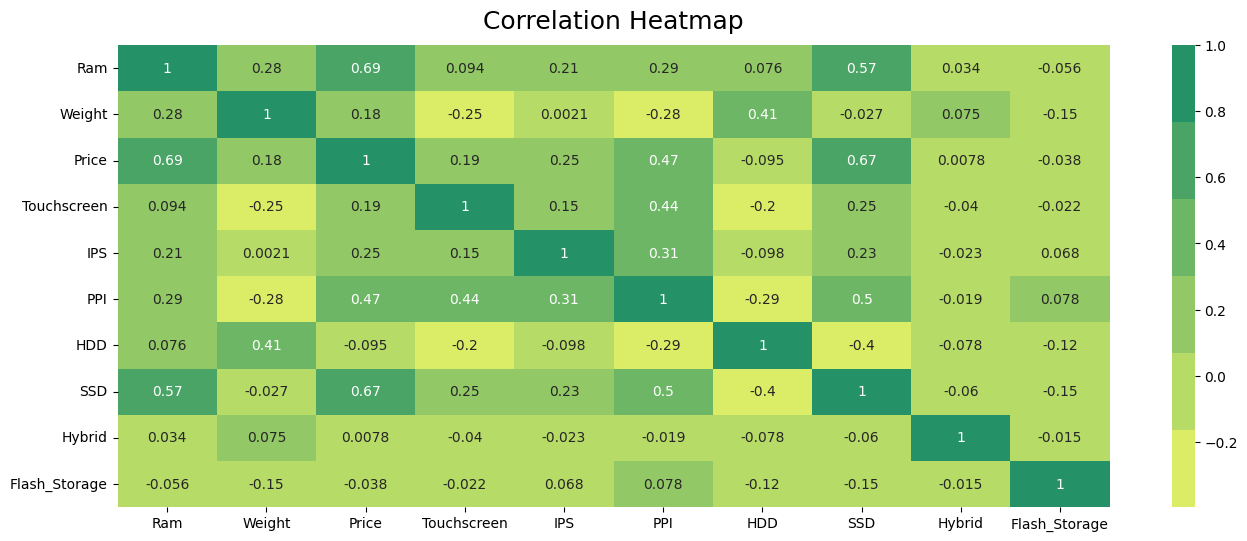

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(16, 6))
colormap = sns.color_palette("summer_r")
sns.heatmap(lap_data.corr(), annot=True, cmap=colormap).set_title('Correlation Heatmap', fontdict={'fontsize':18}, pad=12)
plt.show()

In [ ]:
# Drop columns
lap_data.drop(columns=['Memory','Hybrid','Flash_Storage'],inplace=True)

In [ ]:
lap_data.sample(2)

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,Touchscreen,IPS,PPI,Cpu brand,HDD,SSD
684,Lenovo,2 in 1 Convertible,8,Intel UHD Graphics 620,Windows 10,1.19,79866.72,1,1,165.632118,Intel Core i7,0,512
281,Dell,Notebook,4,AMD Radeon R5 M430,Linux,2.25,22803.84,0,0,141.211998,Intel Core i3,1000,0


### EDA & FE - **GPU**

In [ ]:
# Display GPU value counts
print(lap_data['Gpu'].value_counts())


Intel HD Graphics 620      271
Intel HD Graphics 520      181
Intel UHD Graphics 620      66
Nvidia GeForce GTX 1050     64
Nvidia GeForce GTX 1060     48
                          ... 
AMD Radeon R5 520            1
AMD Radeon R7                1
Intel HD Graphics 540        1
AMD Radeon 540               1
ARM Mali T860 MP4            1
Name: Gpu, Length: 110, dtype: int64


In [ ]:
# Extract GPU brand (first word)
lap_data['Gpu Brand'] = lap_data['Gpu'].apply(lambda x: x.split()[0])

In [ ]:
lap_data.head(2)

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,Touchscreen,IPS,PPI,Cpu brand,HDD,SSD,Gpu Brand
0,Apple,Ultrabook,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Other Intel Processor,0,128,Intel
1,Apple,Ultrabook,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Other Intel Processor,0,0,Intel


In [ ]:
# Drop the 'Gpu' column
lap_data.drop(columns=['Gpu'], inplace=True)

In [ ]:
lap_data['Gpu Brand'].value_counts()

Intel     703
Nvidia    393
AMD       176
ARM         1
Name: Gpu Brand, dtype: int64

In [ ]:
#drop ARM GPU
lap_data = lap_data[lap_data['Gpu Brand'] != 'ARM']

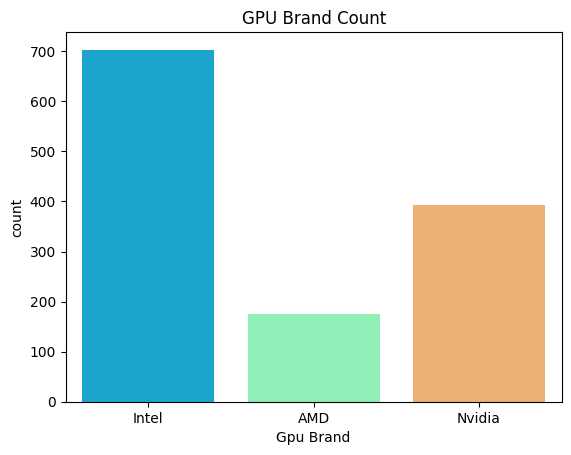

In [ ]:
# Countplot of GPU Brand
sns.countplot(x="Gpu Brand", data=lap_data, palette="rainbow")
plt.title("GPU Brand Count")
plt.show()

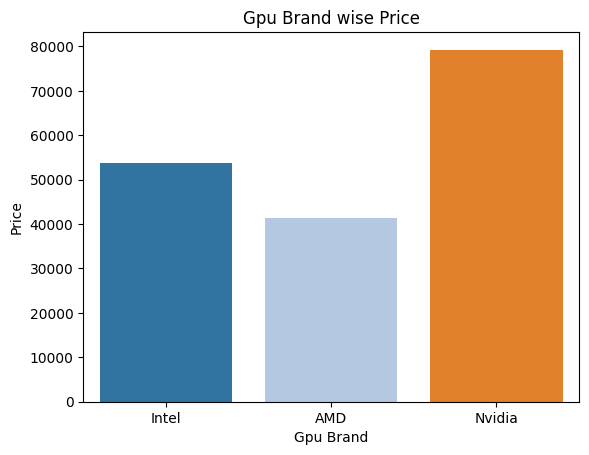

In [ ]:
sns.barplot(x="Gpu Brand", y="Price", data=lap_data, palette="tab20",errorbar=None)
plt.title("Gpu Brand wise Price")
plt.show()

### EDA & FE -  **Operating System**

In [ ]:
lap_data['OpSys'].value_counts()

Windows 10      1047
No OS             63
Linux             61
Windows 7         45
Chrome OS         26
macOS             13
Mac OS X           8
Windows 10 S       8
Android            1
Name: OpSys, dtype: int64

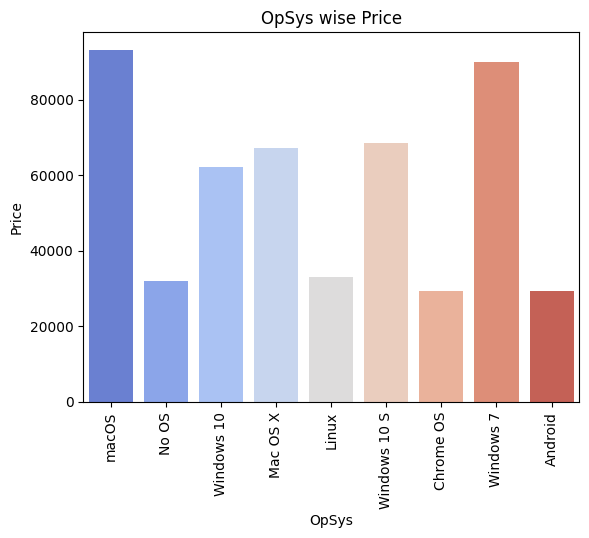

In [ ]:
# Bar plot based on Price Vs OS
sns.barplot(x="OpSys", y="Price", data=lap_data, palette="coolwarm", errorbar=None)
plt.xticks(rotation='vertical')
plt.title("OpSys wise Price")
plt.show()

In [ ]:
# Define a function to categorize operating systems
def cat_os(inp):
    if inp == 'Windows 10' or inp == 'Windows 7' or inp == 'Windows 10 S':
        return 'Windows'
    elif inp == 'macOS' or inp == 'Mac OS X':
        return 'Mac'
    else:
        return 'Others'

In [ ]:
lap_data['os'] = lap_data['OpSys'].apply(cat_os)

In [ ]:
lap_data.head(2)

,Company,TypeName,Ram,OpSys,Weight,Price,Touchscreen,IPS,PPI,Cpu brand,HDD,SSD,Gpu Brand,os
0,Apple,Ultrabook,8,macOS,1.37,71378.6832,0,1,226.983005,Other Intel Processor,0,128,Intel,Mac
1,Apple,Ultrabook,8,macOS,1.34,47895.5232,0,0,127.677940,Other Intel Processor,0,0,Intel,Mac


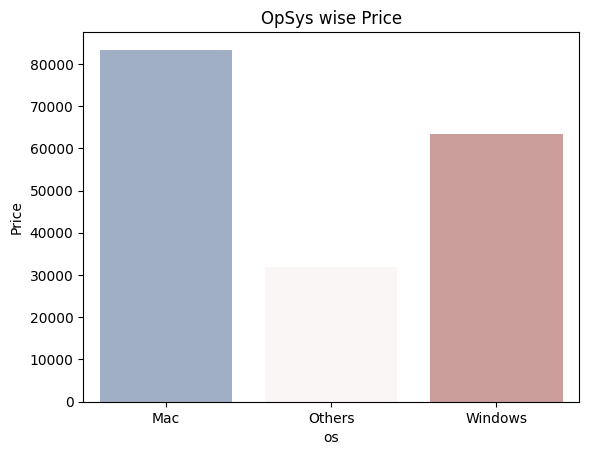

In [ ]:
# Bar Plot
sns.barplot(x="os", y="Price", data=lap_data, palette="vlag", errorbar=None )
plt.title("OpSys wise Price")
plt.show()

In [ ]:
# Drop OpSys Column
lap_data.drop(columns=['OpSys'],inplace=True)

In [ ]:
lap_data.sample(2)

,Company,TypeName,Ram,Weight,Price,Touchscreen,IPS,PPI,Cpu brand,HDD,SSD,Gpu Brand,os
752,Asus,Notebook,4,2.45,30849.120,0,0,100.45467,Intel Core i5,1000,0,Nvidia,Others
1055,HP,Notebook,4,2.31,37570.392,0,0,100.45467,Intel Core i3,500,0,Intel,Windows


### EDA - **Weight**

In [ ]:
import plotly.express as px

# histogram
fig = px.histogram(lap_data, x="Weight", title="Price Distribution", marginal="rug", nbins=20)
fig.update_traces(marker_color='purple', marker_line_color='black', marker_line_width=0.5)
fig.update_layout(title_font_size=20, title_x=0.5)
fig.show()

In [ ]:
# Scatterplot
fig = px.scatter(lap_data, x="Weight", y="Price", color="Price", title="Weight vs Price", marginal_x="rug", marginal_y="rug")
fig.update_traces(marker=dict(symbol='cross'), selector=dict(mode='markers'))
fig.update_layout(title_font_size=20, title_x=0.5)
fig.show()

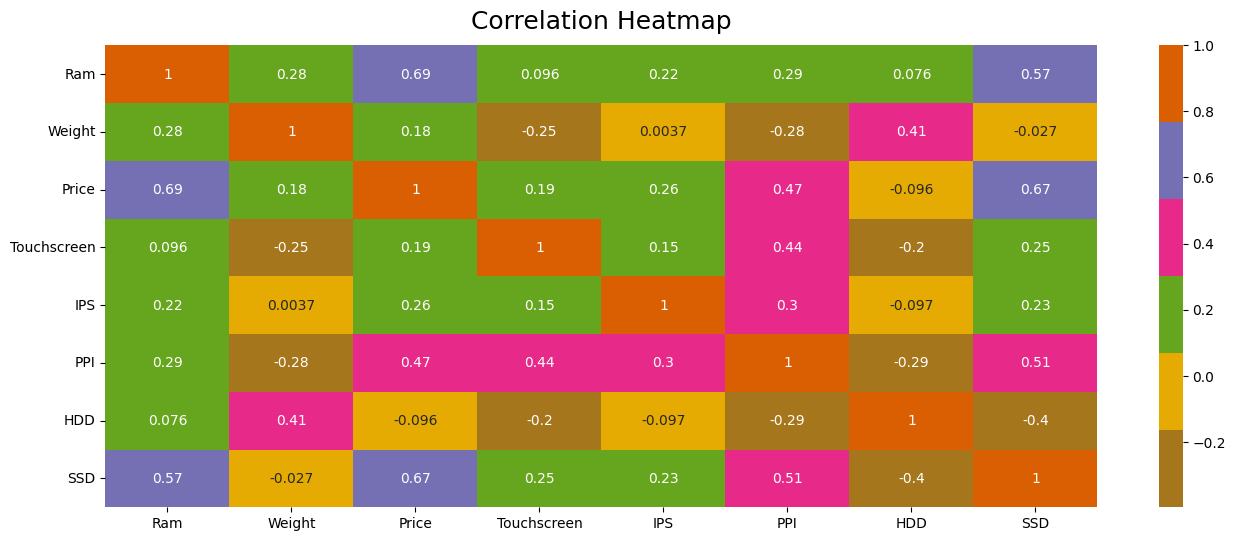

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(16, 6))
colormap = sns.color_palette("Dark2_r")
sns.heatmap(lap_data.corr(), annot=True, cmap=colormap).set_title('Correlation Heatmap', fontdict={'fontsize':18}, pad=12)
plt.show()

In [ ]:
df = lap_data.copy()

**Label Encoding** is a technique that is used to convert categorical columns into numerical ones so that they can be fitted by machine learning models which only take numerical data. It is an important pre-processing step in a machine-learning project.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns

# Create a copy of the DataFrame to avoid modifying the original data
df_encoded = df.copy()

# Apply label encoding to each categorical column
label_encoders = {}
for col in categorical_columns:
    label_encoders[col] = LabelEncoder()
    df_encoded[col] = label_encoders[col].fit_transform(df[col])

# Display the encoded DataFrame
print(df_encoded)

      Company  TypeName  Ram  Weight        Price  Touchscreen  IPS  \
0           1         4    8    1.37   71378.6832            0    1   
1           1         4    8    1.34   47895.5232            0    0   
2           7         3    8    1.86   30636.0000            0    0   
3           1         4   16    1.83  135195.3360            0    1   
4           1         4    8    1.37   96095.8080            0    1   
...       ...       ...  ...     ...          ...          ...  ...   
1298       10         0    4    1.80   33992.6400            1    1   
1299       10         0   16    1.30   79866.7200            1    1   
1300       10         3    2    1.50   12201.1200            0    0   
1301        7         3    6    2.19   40705.9200            0    0   
1302        2         3    4    2.20   19660.3200            0    0   

             PPI  Cpu brand   HDD  SSD  Gpu Brand  os  
0     226.983005          4     0  128          1   0  
1     127.677940          4     0  

## Model Building

In [ ]:
#Import all ML algoritham
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

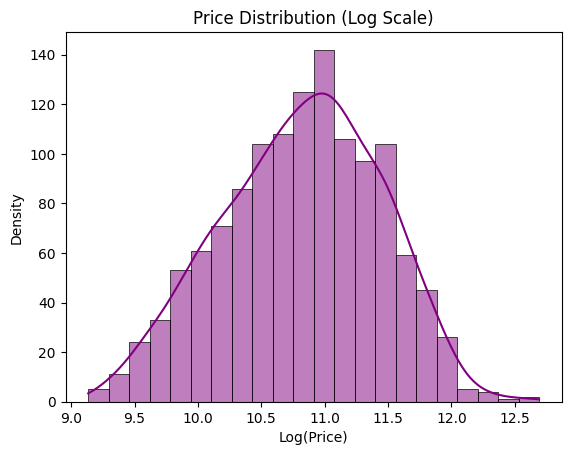

In [ ]:
#Apply Log in price function
# Plotting the distribution of the logarithm of the price
sns.histplot(np.log(df_encoded['Price']), color='purple', edgecolor='black', linewidth=0.5, kde=True)
plt.title("Price Distribution (Log Scale)")
plt.xlabel("Log(Price)")
plt.ylabel("Density")
plt.show()

In [ ]:
# Drop the 'Price' column to get features
X = df_encoded.drop(columns=['Price'])

# Take the natural logarithm of the 'Price' column to get the target variable
y = np.log(df_encoded['Price'])

In [ ]:
X

,Company,TypeName,Ram,Weight,Touchscreen,IPS,PPI,Cpu brand,HDD,SSD,Gpu Brand,os
0,1,4,8,1.37,0,1,226.983005,4,0,128,1,0
1,1,4,8,1.34,0,0,127.677940,4,0,0,1,0
2,7,3,8,1.86,0,0,141.211998,2,0,256,1,1
3,1,4,16,1.83,0,1,220.534624,4,0,512,0,0
4,1,4,8,1.37,0,1,226.983005,4,0,256,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1298,10,0,4,1.80,1,1,157.350512,3,0,128,1,2
1299,10,0,16,1.30,1,1,276.053530,3,0,512,1,2
1300,10,3,2,1.50,0,0,111.935204,4,0,0,1,2
1301,7,3,6,2.19,0,0,100.454670,3,1000,0,0,2


In [ ]:
y

0       11.175755
1       10.776777
2       10.329931
3       11.814476
4       11.473101
          ...    
1298    10.433899
1299    11.288115
1300     9.409283
1301    10.614129
1302     9.886358
Name: Price, Length: 1272, dtype: float64

###Train & Test Split

In [ ]:
# Training - 80% Data & Testing - 20% Data
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [ ]:
#creating dictionary for storing different models accuracy
model_comparison={}

In [ ]:
# Check for missing values in X_train
missing_values = X_train.isna().sum()

# Print the number of missing values in each column
print(missing_values)

Company        0
TypeName       0
Ram            0
Weight         0
Touchscreen    0
IPS            0
PPI            0
Cpu brand      0
HDD            0
SSD            0
Gpu Brand      0
os             0
dtype: int64


### Model 1 : Linear Regression

In [ ]:
model = LinearRegression()


model.fit(X_train,y_train)

y_pred = model.predict(X_test)

accuracies = cross_val_score(estimator = model, X = X_train, y = y_train, cv = 5)

print(f"R2 Score : {r2_score(y_test,y_pred)*100:.2f}%")
print(f"MAE : {mean_absolute_error(y_test,y_pred)*100:.2f}%")
print(f"MSE : {mean_squared_error(y_test,y_pred)*100:.2f}%")
print("Cross Val Accuracy: {:.2f} %".format(accuracies.mean()*100))

model_comparison['Linear Regression']=[r2_score(y_test,y_pred),mean_squared_error(y_test,y_pred),mean_absolute_error(y_test,y_pred),(accuracies.mean())]

R2 Score : 62.23%
MAE : 30.69%
MSE : 14.96%
Cross Val Accuracy: 59.15 %


### Model 2 : KNN Regression

In [ ]:
model = KNeighborsRegressor(n_neighbors=3)


model.fit(X_train,y_train)

y_pred = model.predict(X_test)

accuracies = cross_val_score(estimator = model, X = X_train, y = y_train, cv = 5)

print(f"R2 Score : {r2_score(y_test,y_pred)*100:.2f}%")
print(f"MAE : {mean_absolute_error(y_test,y_pred)*100:.2f}%")
print(f"MSE : {mean_squared_error(y_test,y_pred)*100:.2f}%")
print("Cross Val Accuracy: {:.2f} %".format(accuracies.mean()*100))

model_comparison['KNN Regression']=[r2_score(y_test,y_pred),mean_squared_error(y_test,y_pred),mean_absolute_error(y_test,y_pred),(accuracies.mean())]

R2 Score : 78.36%
MAE : 21.46%
MSE : 8.57%
Cross Val Accuracy: 71.65 %


### Model 3 : DecisionTree Regression

In [ ]:
model = DecisionTreeRegressor(max_depth=8)

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

accuracies = cross_val_score(estimator = model, X = X_train, y = y_train, cv = 5)

print(f"R2 Score : {r2_score(y_test,y_pred)*100:.2f}%")
print(f"MAE : {mean_absolute_error(y_test,y_pred)*100:.2f}%")
print(f"MSE : {mean_squared_error(y_test,y_pred)*100:.2f}%")
print("Cross Val Accuracy: {:.2f} %".format(accuracies.mean()*100))

model_comparison['DecisionTree Regression']=[r2_score(y_test,y_pred),mean_squared_error(y_test,y_pred),mean_absolute_error(y_test,y_pred),(accuracies.mean())]

R2 Score : 80.99%
MAE : 20.66%
MSE : 7.53%
Cross Val Accuracy: 78.83 %


### Model 4 : SVR Regression

In [ ]:
model = SVR(kernel='rbf',C=10000,epsilon=0.1)

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

accuracies = cross_val_score(estimator = model, X = X_train, y = y_train, cv = 5)

print(f"R2 Score : {r2_score(y_test,y_pred)*100:.2f}%")
print(f"MAE : {mean_absolute_error(y_test,y_pred)*100:.2f}%")
print(f"MSE : {mean_squared_error(y_test,y_pred)*100:.2f}%")
print("Cross Val Accuracy: {:.2f} %".format(accuracies.mean()*100))

model_comparison['SVR Regression']=[r2_score(y_test,y_pred),mean_squared_error(y_test,y_pred),mean_absolute_error(y_test,y_pred),(accuracies.mean())]

R2 Score : 77.11%
MAE : 22.41%
MSE : 9.07%
Cross Val Accuracy: 69.25 %


### Model 5 : RandomForest Regression

In [ ]:
model = RandomForestRegressor(n_estimators=100,
                              random_state=3,
                              max_samples=0.5,
                              max_features=0.10,
                              max_depth=15)

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

accuracies = cross_val_score(estimator = model, X = X_train, y = y_train, cv = 5)

print(f"R2 Score : {r2_score(y_test,y_pred)*100:.2f}%")
print(f"MAE : {mean_absolute_error(y_test,y_pred)*100:.2f}%")
print(f"MSE : {mean_squared_error(y_test,y_pred)*100:.2f}%")
print("Cross Val Accuracy: {:.2f} %".format(accuracies.mean()*100))

model_comparison['RandomForest Regression']=[r2_score(y_test,y_pred),mean_squared_error(y_test,y_pred),mean_absolute_error(y_test,y_pred),(accuracies.mean())]

R2 Score : 88.28%
MAE : 16.10%
MSE : 4.64%
Cross Val Accuracy: 85.99 %


## Model Comparison

In [ ]:
Model_com_ld=pd.DataFrame(model_comparison).T
Model_com_ld.columns=['R2 Score','MAE','MSE','Cross Val Accuracy']
Model_com_ld=Model_com_ld.sort_values(by='R2 Score',ascending=False)

In [ ]:
Model = Model_com_ld.style.format("{:.2%}").background_gradient(cmap='RdPu')

In [ ]:
Max = Model_com_ld.style.highlight_max().set_caption("Maximum Score in each Column").format("{:.2%}")

In [ ]:
Min = Model_com_ld.style.highlight_min().set_caption("Minimum Score in each Column").format("{:.2%}")

In [ ]:
Model

,R2 Score,MAE,MSE,Cross Val Accuracy
RandomForest Regression,88.28%,4.64%,16.10%,85.99%
DecisionTree Regression,80.99%,7.53%,20.66%,78.83%
KNN Regression,78.36%,8.57%,21.46%,71.65%
SVR Regression,77.11%,9.07%,22.41%,69.25%
Linear Regression,62.23%,14.96%,30.69%,59.15%


In [ ]:
Min

,R2 Score,MAE,MSE,Cross Val Accuracy
RandomForest Regression,88.28%,4.64%,16.10%,85.99%
DecisionTree Regression,80.99%,7.53%,20.66%,78.83%
KNN Regression,78.36%,8.57%,21.46%,71.65%
SVR Regression,77.11%,9.07%,22.41%,69.25%
Linear Regression,62.23%,14.96%,30.69%,59.15%


In [ ]:
Max

,R2 Score,MAE,MSE,Cross Val Accuracy
RandomForest Regression,88.28%,4.64%,16.10%,85.99%
DecisionTree Regression,80.99%,7.53%,20.66%,78.83%
KNN Regression,78.36%,8.57%,21.46%,71.65%
SVR Regression,77.11%,9.07%,22.41%,69.25%
Linear Regression,62.23%,14.96%,30.69%,59.15%


#Conclusion

Based on the evaluation metrics obtained from the various regression models in your machine learning project, the following conclusions can be drawn:

1. **RandomForest Regression**:
   - Achieved the highest R2 score of 88.28%, indicating that it explains a significant portion of the variance in the data.
   - Has the lowest Mean Absolute Error (MAE) of 4.64%, indicating that, on average, the predictions are very close to the actual values.
   - Demonstrated the lowest Mean Squared Error (MSE) of 16.10%, indicating that it produces smaller errors on average compared to other models.
   - Achieved a high Cross-Validation Accuracy of 85.99%, suggesting good generalization performance.

2. **DecisionTree Regression**:
   - Also performed well with an R2 score of 80.99%, indicating a good level of explained variance.
   - Had a higher MAE and MSE compared to RandomForest, but still produced reasonable predictions.
   - Cross-Validation Accuracy of 78.83% suggests decent generalization performance but slightly lower compared to RandomForest.

3. **KNN Regression**:
   - Achieved an R2 score of 78.36%, indicating a satisfactory level of explained variance.
   - Had higher MAE and MSE compared to DecisionTree, indicating slightly larger errors on average.
   - Cross-Validation Accuracy of 71.65% suggests moderate generalization performance.

4. **SVR Regression**:
   - Obtained an R2 score of 77.11%, showing a reasonable level of explained variance.
   - Had slightly higher MAE and MSE compared to KNN, indicating slightly larger errors.
   - Cross-Validation Accuracy of 69.25% suggests decent generalization performance but lower compared to other models.

5. **Linear Regression**:
   - Produced the lowest R2 score of 62.23%, indicating that it explains less variance compared to other models.
   - Demonstrated the highest MAE and MSE among all models, indicating larger errors on average.
   - Cross-Validation Accuracy of 59.15% suggests weaker generalization performance compared to other models.

In summary, RandomForest Regression performed the best overall, exhibiting the highest R2 score, lowest MAE, MSE, and high cross-validation accuracy, indicating its effectiveness in predicting the target variable. DecisionTree Regression also showed promising results, followed by KNN and SVR Regression. Linear Regression, while providing insights, may not be the best choice for this particular dataset due to its comparatively lower performance metrics. Therefore, **RandomForest Regression** could be the preferred model for making predictions in this ML project.